In [120]:
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV, train_test_split 
from sklearn.metrics import accuracy_score,r2_score,classification_report,confusion_matrix,roc_auc_score,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib

In [142]:
dataset=pd.read_csv('reduced_dataset.csv')
dataset.head()

,blacmy,uhpt_e350q,estx,tet(c),qnrb19,dfra17,qnrs1,dfra14,blatem,tet(d),...,aada2,blactx-m-8,nfsa_g126r,sul2,ampicillin_Resistance,tetracycline_Resistance,cefazolin_Resistance,ceftriaxone_Resistance,ciprofloxacin_Resistance,trimethoprim-sulfamethoxazole_Resistance
0,0,1,0,0,0,1,0,0,0,0,...,0,0,0,1,1.0,1.0,1.0,1.0,1.0,1.0
1,0,1,0,0,0,1,1,1,0,0,...,0,0,0,1,1.0,1.0,1.0,1.0,1.0,1.0
2,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,1.0,1.0,1.0,1.0,1.0,1.0
3,0,1,0,0,0,1,0,0,0,0,...,0,0,0,1,1.0,0.0,1.0,1.0,1.0,1.0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1.0,1.0,1.0,1.0,1.0,0.0


In [143]:
target_cols = [
    'ampicillin_Resistance',
    'tetracycline_Resistance',
    'cefazolin_Resistance',
    'ceftriaxone_Resistance',
    'ciprofloxacin_Resistance',
    'trimethoprim-sulfamethoxazole_Resistance'
]

X = dataset.drop(columns=target_cols)
y = dataset[target_cols]


In [144]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [145]:
rf_params = {
    "n_estimators": [50, 100, 200, 300, 400, 500],
    "max_depth": [None, 5,10,20, 40,60],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4,10],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True]
}


In [110]:
rf = RandomForestClassifier(random_state=42,class_weight="balanced")

search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=20,
    refit="accuracy",
    n_jobs=-1,
    cv=5,
    scoring=['accuracy', 'f1', 'roc_auc','recall'],
)

search.fit(X_train, y_train)


c:\Users\Adith\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [None, 5, 10, 20, 40, 60],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4, 10],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 300, 400,
                                                         500]},
                   refit='accuracy',
                   scoring=['accuracy', 'f1', 'roc_auc', 'recall'])

In [146]:
models = {}

for col in target_cols:
    
    rf = RandomForestClassifier(class_weight="balanced", min_samples_split=5,
                       n_estimators=400, random_state=42)
    rf.fit(X_train, y_train[col])
    
    models[col] = rf


In [147]:
for col in target_cols:
    print(f"Antibiotic: {col}")
    
    y_pred = models[col].predict(X_test)
    
    print(classification_report(y_test[col], y_pred))


Antibiotic: ampicillin_Resistance
              precision    recall  f1-score   support

         0.0       0.95      0.96      0.96       255
         1.0       0.96      0.95      0.96       239

    accuracy                           0.96       494
   macro avg       0.96      0.96      0.96       494
weighted avg       0.96      0.96      0.96       494

Antibiotic: tetracycline_Resistance
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98       341
         1.0       0.96      0.97      0.96       153

    accuracy                           0.98       494
   macro avg       0.97      0.97      0.97       494
weighted avg       0.98      0.98      0.98       494

Antibiotic: cefazolin_Resistance
              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94       346
         1.0       0.86      0.86      0.86       148

    accuracy                           0.92       494
   macro avg       0.90  

In [ ]:
y_pred=models['ampicillin_Resistance'].predict(X_test)

In [149]:
cm = confusion_matrix(y_test['ampicillin_Resistance'], y_pred)

Text(50.722222222222214, 0.5, 'True')

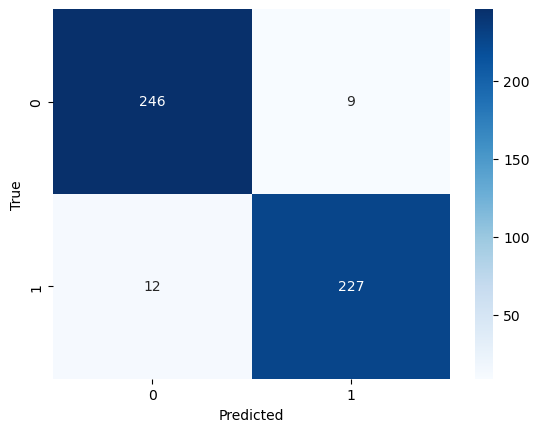

In [150]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted') 
plt.ylabel('True')

In [151]:

ac=accuracy_score(y_pred,y_test['ampicillin_Resistance'])
ac
ro=roc_auc_score(y_pred,y_test['ampicillin_Resistance'])

print("accuracy_score {ac}, f1_score {f1}, roc_auc_score {ro}".format(ac=ac,f1=f1_score(y_test['ampicillin_Resistance'],y_pred),ro=ro))

accuracy_score 0.9574898785425101, f1_score 0.9557894736842105, roc_auc_score 0.9576763894363421


In [152]:
joblib.dump(models, "Antibiotic_models.joblib")

['Antibiotic_models.joblib']

In [153]:
loaded_model = joblib.load("Antibiotic_models.joblib")
loaded_model['ampicillin_Resistance'].predict(X_test)

array([1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0.,
       0., 1., 0., 1., 0., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1.,
       1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0.,
       1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.,
       1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
       0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 1., 1., 1.,
       1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0.,
       0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 0., 1., 0., 0., 1.,
       0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0.,
       0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0.,
       0., 1., 0., 0., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1.,
       0., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1.,
       0., 0., 1., 1., 1.

In [154]:
importances = models['ampicillin_Resistance'].feature_importances_
importances

array([9.42209540e-04, 5.28190061e-03, 6.08679351e-04, 7.41115066e-06,
       1.04349483e-03, 2.88586516e-02, 4.30091164e-03, 2.67699243e-03,
       6.14743777e-03, 2.31667077e-03, 9.93231235e-03, 3.36793049e-03,
       3.84514591e-02, 1.82343605e-03, 3.91099197e-04, 3.53224414e-04,
       3.10702627e-01, 3.54262100e-02, 1.12270380e-02, 2.43242812e-04,
       2.55757282e-03, 6.84437694e-03, 6.95071424e-04, 2.89823644e-03,
       4.28613344e-04, 6.70898747e-04, 2.04971120e-03, 3.35843240e-02,
       6.64082053e-03, 3.90864068e-02, 3.40106770e-03, 6.36281676e-04,
       8.72414296e-04, 2.21870554e-03, 1.14674548e-02, 2.25003172e-03,
       5.37806578e-04, 7.97802053e-04, 5.97036266e-03, 3.89763187e-03,
       2.88601882e-04, 9.79500140e-03, 3.78046640e-03, 1.43909659e-03,
       5.98862134e-04, 4.25676283e-03, 1.44294082e-02, 1.74202140e-02,
       6.77436640e-03, 1.25926253e-03, 1.37464115e-03, 2.18562048e-03,
       2.10215416e-03, 1.19350709e-03, 1.31713005e-03, 1.47279182e-03,
      

In [156]:
indices = np.argsort(importances)[-20:]
indices

array([41, 10, 18, 34, 46, 47, 78, 59, 70, 75,  5, 84, 27, 67, 17, 12, 29,
       79, 90, 16])

In [157]:
for i in reversed(indices):
    print(f"{X.columns[i]}: {importances[i]:.4f}")

blatem-1: 0.3107
sul2: 0.0521
aph(3'')-ib: 0.0404
aph(6)-id: 0.0391
ampc_t-32a: 0.0385
blacmy-2: 0.0354
blactx-m-15: 0.0345
parc_s80i: 0.0336
sul1: 0.0318
dfra17: 0.0289
gyra_s83l: 0.0273
mph(a): 0.0260
gyra_d87n: 0.0252
aada5: 0.0251
blashv-1: 0.0174
emrd: 0.0144
pare_i529l: 0.0115
tet(a): 0.0112
blactx-m-27: 0.0099
parc_e84v: 0.0098


In [158]:
all_important_genes = set()

for col in target_cols:
    rf = models[col]
    feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
    
    top_genes = feat_imp[feat_imp > 0.001].index.tolist()
    all_important_genes.update(top_genes)

all_important_genes = list(all_important_genes)
X_reduced = X[all_important_genes]
X_reduced

,blacmy,uhpt_e350q,estx,tet(c),qnrb19,qnrs1,dfra17,dfra14,blatem,tet(d),...,mdtm,blatemp_c32t,dfra51,blactx-m-1,sul1,acrb_r620c,tet(m),aada2,blactx-m-8,sul2
0,0,1,0,0,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,1
1,0,1,0,0,0,1,1,1,0,0,...,1,0,0,0,1,0,0,0,0,1
2,0,1,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,1
4,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2462,0,1,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2463,0,1,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2464,0,0,0,0,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
2465,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [159]:
print("Original dataset size",X.shape[1])
print("Reduced dataset size",X_reduced.shape[1])

Original dataset size 91
Reduced dataset size 89


In [141]:
pd.concat([X_reduced, y], axis=1).to_csv("reduced_dataset.csv", index=False)

In [91]:
et=ExtraTreesClassifier(n_estimators=100,criterion='entropy')

In [92]:
et.fit(X_train,y_train)

ExtraTreesClassifier(criterion='entropy')

In [93]:
et.score(X_test,y_test)

0.9540087010565569

In [95]:
from sklearn.metrics import roc_auc_score,f1_score
y_predict=et.predict(X_test)
ac=accuracy_score(y_predict,y_test)
ac
ro=roc_auc_score(y_predict,y_test)
print(ac,f1_score(y_test,y_predict),ro)
print("accuracy_score {ac}, f1_score {f1}, roc_auc_score {ro}".format(ac=ac,f1=f1_score(y_test,y_predict),ro=ro))

0.9540087010565569 0.9511873350923483 0.9541401026881972
accuracy_score 0.9540087010565569, f1_score 0.9511873350923483, roc_auc_score 0.9541401026881972


In [96]:
ac=accuracy_score(y_predict,y_test)
ac

0.9540087010565569

In [97]:
import pandas as pd

feature_importance = pd.Series(
    et.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(20)


blatem-1       0.266144
blacmy-2       0.103007
blaher-3       0.042656
gyra_s83l      0.026217
blactx-m-15    0.024880
sul2           0.022970
tet(a)         0.022868
ampc_c-42t     0.022167
blacmy         0.020483
blactx-m-1     0.019730
dfra17         0.017132
parc_s80i      0.015032
mph(a)         0.014736
aada5          0.013779
aph(6)-id      0.013573
emrd           0.013327
aph(3'')-ib    0.012568
ampc_t-32a     0.012511
sul1           0.012081
gyra_d87n      0.011886
dtype: float64

In [98]:

from sklearn.metrics import classification_report


print(classification_report(y_test, et.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.95      0.96      0.96       847
         1.0       0.96      0.95      0.95       762

    accuracy                           0.95      1609
   macro avg       0.95      0.95      0.95      1609
weighted avg       0.95      0.95      0.95      1609



Text(50.72222222222221, 0.5, 'True Label')

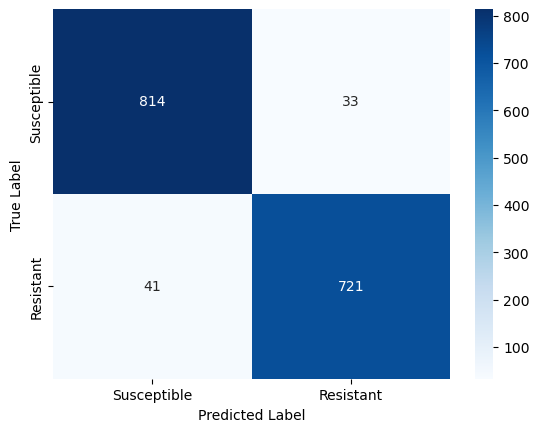

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, et.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Susceptible', 'Resistant'], yticklabels=['Susceptible', 'Resistant'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')